In [1]:
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import numpy as np

import sys
sys.path.append('../src')

from dataReading import *
from inference import *


---

# Ordered lattice

In [2]:
L = 8           # System linear size
Tmin = 1.670    # Minimum temperature
Tmax = 30.000   # Maximum temperature
M = 40          # Number of temperatures
isDis = False   # Is disorder present?

betaArray = np.linspace(1/Tmax, 1/Tmin, M)
TArray = 1/betaArray

In [3]:
TRank = 30
beta = betaArray[TRank]

configs = load_lattice_configs(L, Tmin, Tmax, M, isDis, TRank)

trueCouplings = load_lattice_couplings(L, Tmin, Tmax, M, isDis)
true_gamma = gamma(trueCouplings, trueCouplings)

MF_inferredCouplings = evaluate_MF_inference(configs, beta)
MF_gamma = gamma(trueCouplings, MF_inferredCouplings)

PL_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.0)
PL_gamma = gamma(trueCouplings, PL_inferredCouplings)

PLWithLasso_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.1)
PLWithLasso_gamma = gamma(trueCouplings, PLWithLasso_inferredCouplings)

Training Progress: 100%|██████████| 5000/5000 [01:58<00:00, 42.14epoch/s]


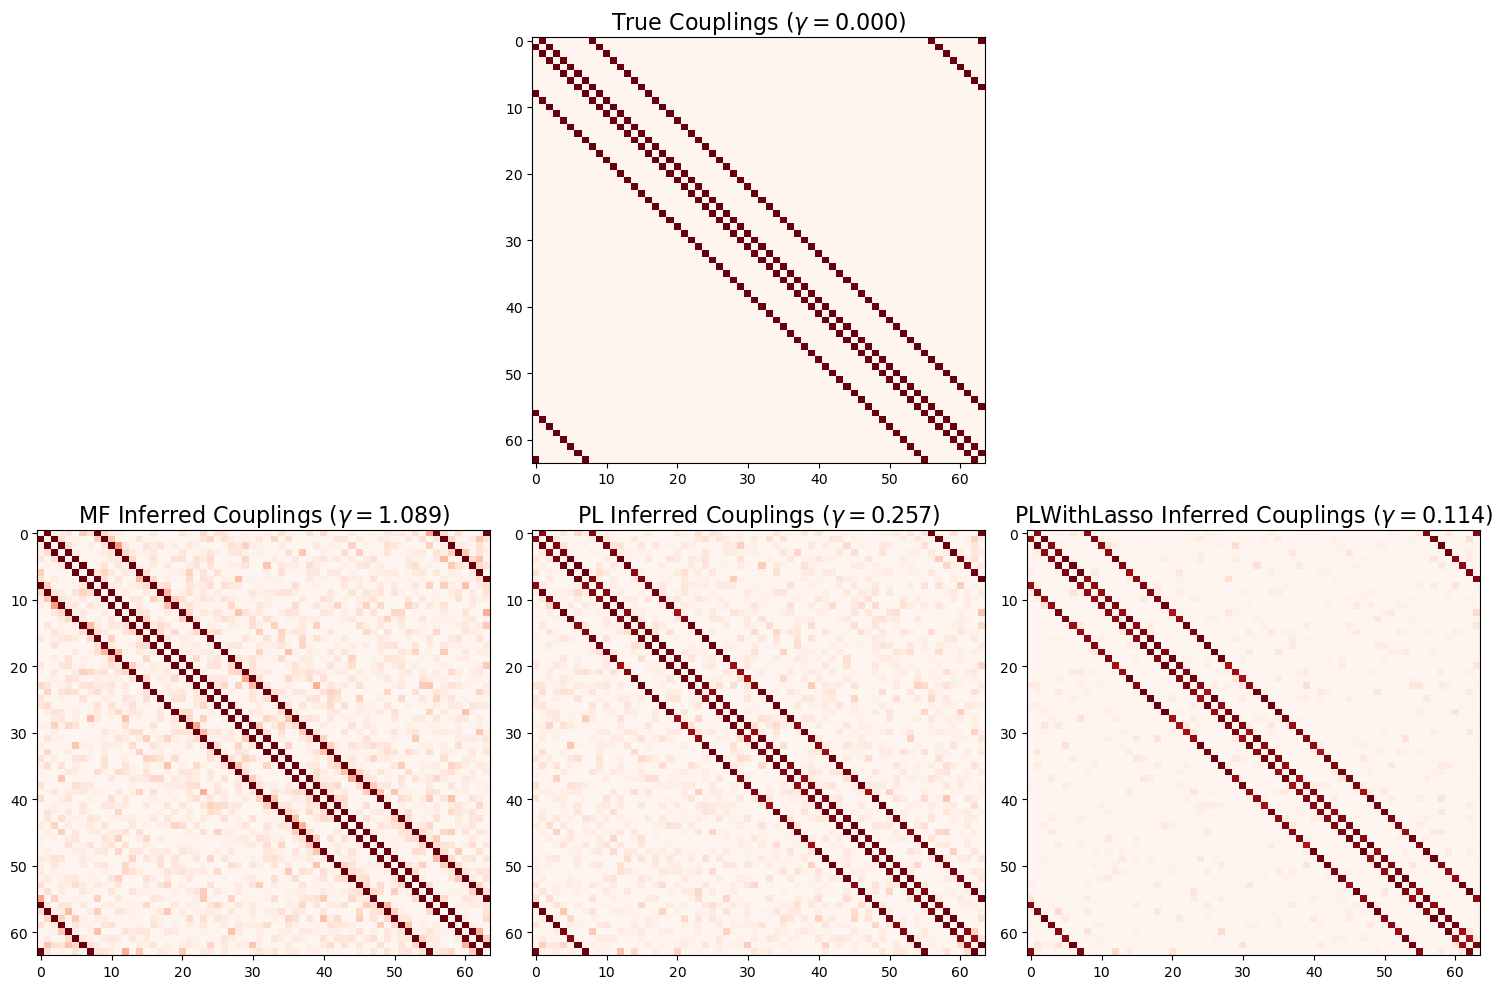

In [4]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=fig)

# Define vmin and vmax for consistent colormap scaling
vmin = trueCouplings.min()
vmax = trueCouplings.max()


# Plot trueCouplings in the first row (centered)
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(trueCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax1.set_title(r'True Couplings ($\gamma = {:.3f}$)'.format(true_gamma), fontsize=16)
# ax1.set_xlabel('Index', fontsize=14)
# ax1.set_ylabel('Index', fontsize=14)

# Plot MF_inferredCouplings in the second row
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(MF_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax2.set_title(r'MF Inferred Couplings ($\gamma = {:.3f}$)'.format(MF_gamma), fontsize=16)
# ax2.set_xlabel('Index', fontsize=14)
# ax2.set_ylabel('Index', fontsize=14)

# Plot PL_inferredCouplings in the second row
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(PL_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax3.set_title(r'PL Inferred Couplings ($\gamma = {:.3f}$)'.format(PL_gamma), fontsize=16)
# ax3.set_xlabel('Index', fontsize=14)
# ax3.set_ylabel('Index', fontsize=14)

# Plot PLWithLasso_inferredCouplings in the second row
ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(PLWithLasso_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax4.set_title(r'PLWithLasso Inferred Couplings ($\gamma = {:.3f}$)'.format(PLWithLasso_gamma), fontsize=16)
# ax4.set_xlabel('Index', fontsize=14)
# ax4.set_ylabel('Index', fontsize=14)

plt.tight_layout()
plt.savefig('../imgs/couplingsInference_latticeOrd_T{:.3f}.png'.format(1/beta))


---

# Ordered graph

In [5]:
L = 8           # System linear size
Tmin = 1.670    # Minimum temperature
Tmax = 30.000   # Maximum temperature
M = 40          # Number of temperatures
isDis = False   # Is disorder present?

betaArray = np.linspace(1/Tmax, 1/Tmin, M)
TArray = 1/betaArray

In [6]:
TRank = 30
beta = betaArray[TRank]

configs = load_rrg_configs(L, Tmin, Tmax, M, isDis, TRank)

trueCouplings = load_rrg_couplings(L, Tmin, Tmax, M, isDis)
true_gamma = gamma(trueCouplings, trueCouplings)

MF_inferredCouplings = evaluate_MF_inference(configs, beta)
MF_gamma = gamma(trueCouplings, MF_inferredCouplings)

PL_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.0)
PL_gamma = gamma(trueCouplings, PL_inferredCouplings)

PLWithLasso_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.1)
PLWithLasso_gamma = gamma(trueCouplings, PLWithLasso_inferredCouplings)

Training Progress: 100%|██████████| 5000/5000 [01:59<00:00, 41.67epoch/s]


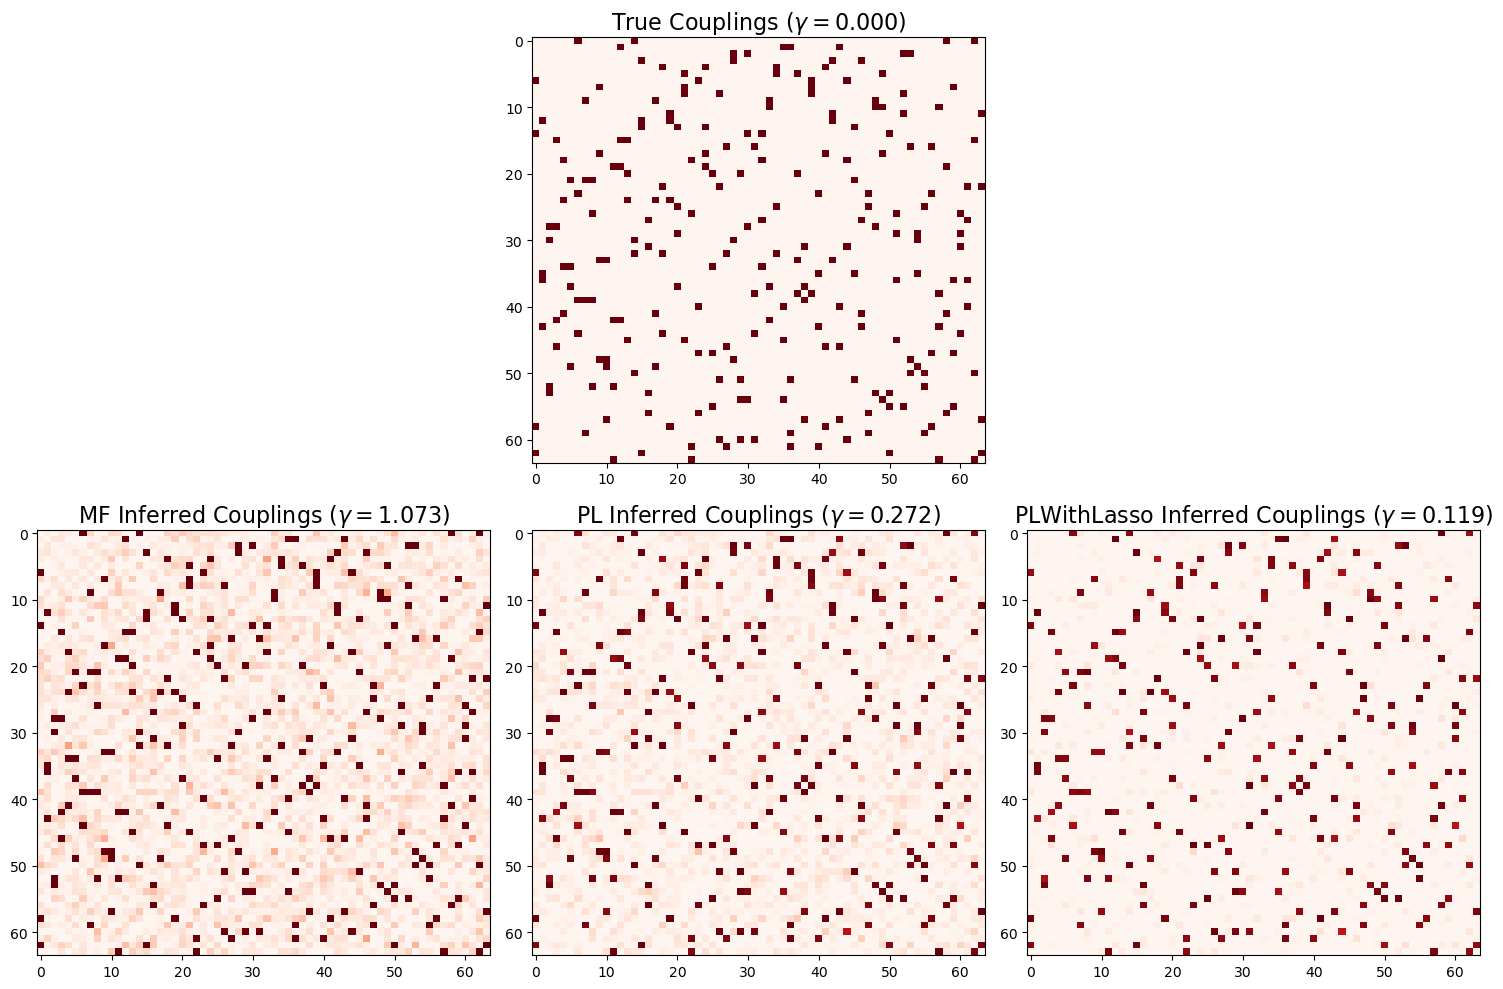

In [7]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=fig)

# Define vmin and vmax for consistent colormap scaling
vmin = trueCouplings.min()
vmax = trueCouplings.max()


# Plot trueCouplings in the first row (centered)
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(trueCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax1.set_title(r'True Couplings ($\gamma = {:.3f}$)'.format(true_gamma), fontsize=16)
# ax1.set_xlabel('Index', fontsize=14)
# ax1.set_ylabel('Index', fontsize=14)

# Plot MF_inferredCouplings in the second row
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(MF_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax2.set_title(r'MF Inferred Couplings ($\gamma = {:.3f}$)'.format(MF_gamma), fontsize=16)
# ax2.set_xlabel('Index', fontsize=14)
# ax2.set_ylabel('Index', fontsize=14)

# Plot PL_inferredCouplings in the second row
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(PL_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax3.set_title(r'PL Inferred Couplings ($\gamma = {:.3f}$)'.format(PL_gamma), fontsize=16)
# ax3.set_xlabel('Index', fontsize=14)
# ax3.set_ylabel('Index', fontsize=14)

# Plot PLWithLasso_inferredCouplings in the second row
ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(PLWithLasso_inferredCouplings, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
ax4.set_title(r'PLWithLasso Inferred Couplings ($\gamma = {:.3f}$)'.format(PLWithLasso_gamma), fontsize=16)
# ax4.set_xlabel('Index', fontsize=14)
# ax4.set_ylabel('Index', fontsize=14)

plt.tight_layout()
plt.savefig('../imgs/couplingsInference_rrgOrd_T{:.3f}.png'.format(1/beta))

--- 

# Disordred lattice

In [8]:
L = 8           # System linear size
Tmin = 1.670    # Minimum temperature
Tmax = 30.000   # Maximum temperature
M = 40          # Number of temperatures
isDis = True    # Is disorder present?

betaArray = np.linspace(1/Tmax, 1/Tmin, M)
TArray = 1/betaArray

In [9]:
TRank = 30
beta = betaArray[TRank]

configs = load_lattice_configs(L, Tmin, Tmax, M, isDis, TRank)

trueCouplings = load_lattice_couplings(L, Tmin, Tmax, M, isDis)
true_gamma = gamma(trueCouplings, trueCouplings)

MF_inferredCouplings = evaluate_MF_inference(configs, beta)
MF_gamma = gamma(trueCouplings, MF_inferredCouplings)

PL_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.0)
PL_gamma = gamma(trueCouplings, PL_inferredCouplings)

PLWithLasso_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.1)
PLWithLasso_gamma = gamma(trueCouplings, PLWithLasso_inferredCouplings)

Training Progress: 100%|██████████| 5000/5000 [01:59<00:00, 41.83epoch/s]


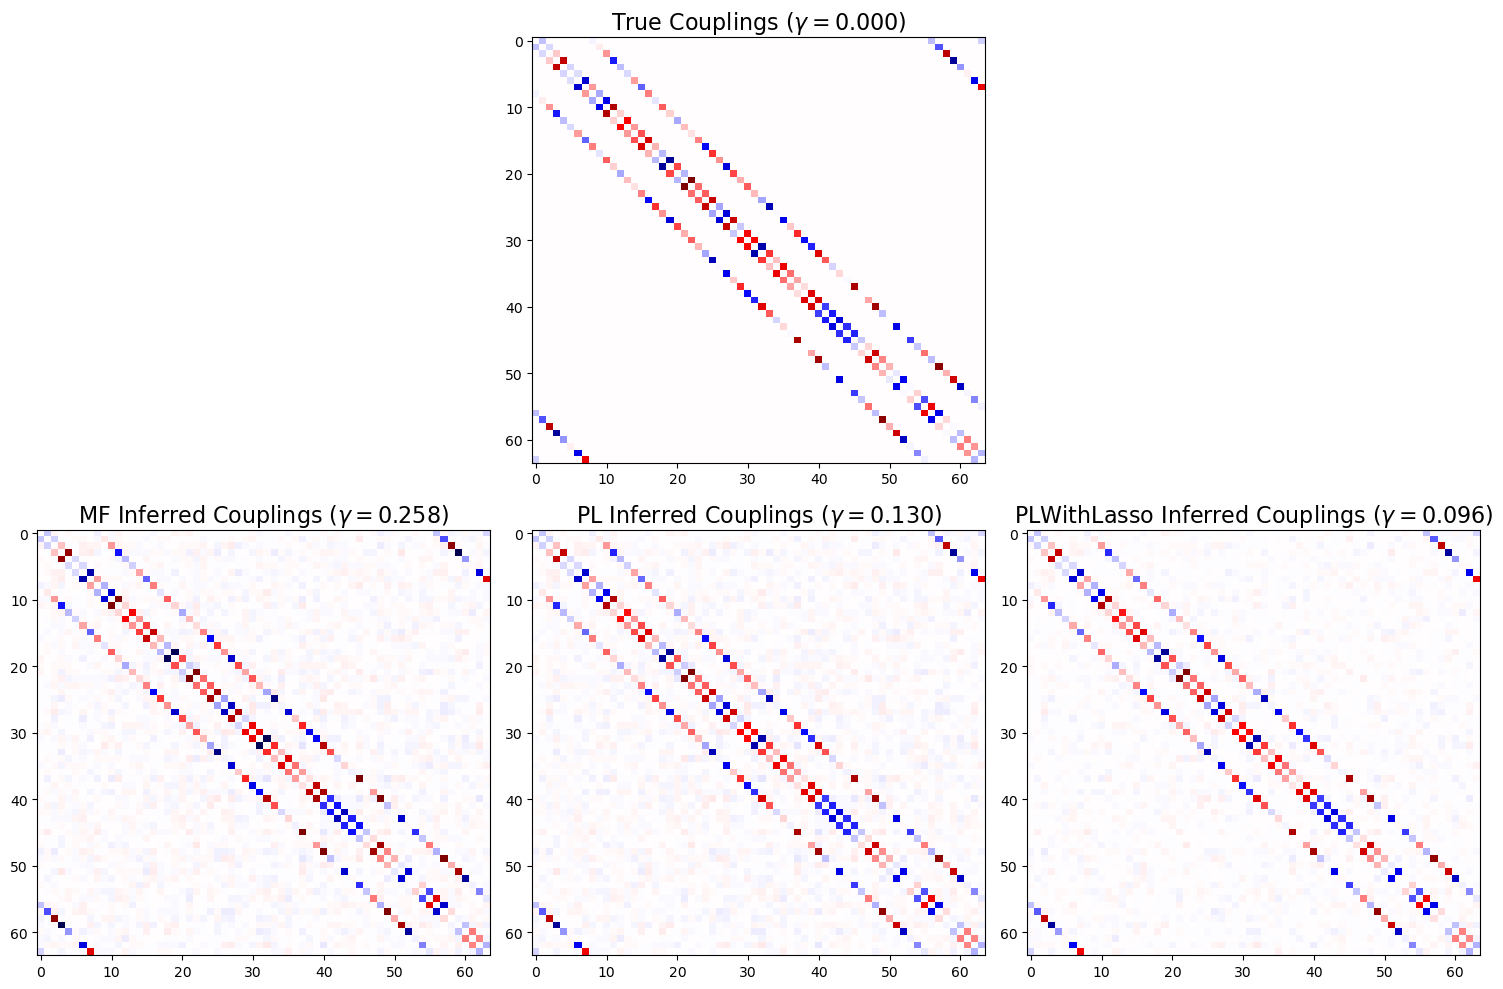

In [10]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=fig)

# Define vmin and vmax for consistent colormap scaling
x = max(abs(trueCouplings.min()), abs(trueCouplings.max()))
vmin = -x
vmax = x

# Plot trueCouplings in the first row (centered)
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(trueCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax1.set_title(r'True Couplings ($\gamma = {:.3f}$)'.format(true_gamma), fontsize=16)
# ax1.set_xlabel('Index', fontsize=14)
# ax1.set_ylabel('Index', fontsize=14)

# Plot MF_inferredCouplings in the second row
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(MF_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax2.set_title(r'MF Inferred Couplings ($\gamma = {:.3f}$)'.format(MF_gamma), fontsize=16)
# ax2.set_xlabel('Index', fontsize=14)
# ax2.set_ylabel('Index', fontsize=14)

# Plot PL_inferredCouplings in the second row
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(PL_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax3.set_title(r'PL Inferred Couplings ($\gamma = {:.3f}$)'.format(PL_gamma), fontsize=16)
# ax3.set_xlabel('Index', fontsize=14)
# ax3.set_ylabel('Index', fontsize=14)

# Plot PLWithLasso_inferredCouplings in the second row
ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(PLWithLasso_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax4.set_title(r'PLWithLasso Inferred Couplings ($\gamma = {:.3f}$)'.format(PLWithLasso_gamma), fontsize=16)
# ax4.set_xlabel('Index', fontsize=14)
# ax4.set_ylabel('Index', fontsize=14)

plt.tight_layout()
plt.savefig('../imgs/couplingsInference_latticeDis_T{:.3f}.png'.format(1/beta))

--- 

# Disordered graph

In [11]:
L = 8           # System linear size
Tmin = 1.670    # Minimum temperature
Tmax = 30.000   # Maximum temperature
M = 40          # Number of temperatures
isDis = True    # Is disorder present?

betaArray = np.linspace(1/Tmax, 1/Tmin, M)
TArray = 1/betaArray

In [12]:
TRank = 30
beta = betaArray[TRank]

configs = load_rrg_configs(L, Tmin, Tmax, M, isDis, TRank)

trueCouplings = load_rrg_couplings(L, Tmin, Tmax, M, isDis)
true_gamma = gamma(trueCouplings, trueCouplings)

MF_inferredCouplings = evaluate_MF_inference(configs, beta)
MF_gamma = gamma(trueCouplings, MF_inferredCouplings)

PL_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.0)
PL_gamma = gamma(trueCouplings, PL_inferredCouplings)

PLWithLasso_inferredCouplings = evaluate_PL_inference(configs, beta, learning_rate = 10., epochs = 5000, decay=0.999, l1_amplitude=0.1)
PLWithLasso_gamma = gamma(trueCouplings, PLWithLasso_inferredCouplings)

Training Progress: 100%|██████████| 5000/5000 [02:02<00:00, 40.84epoch/s]


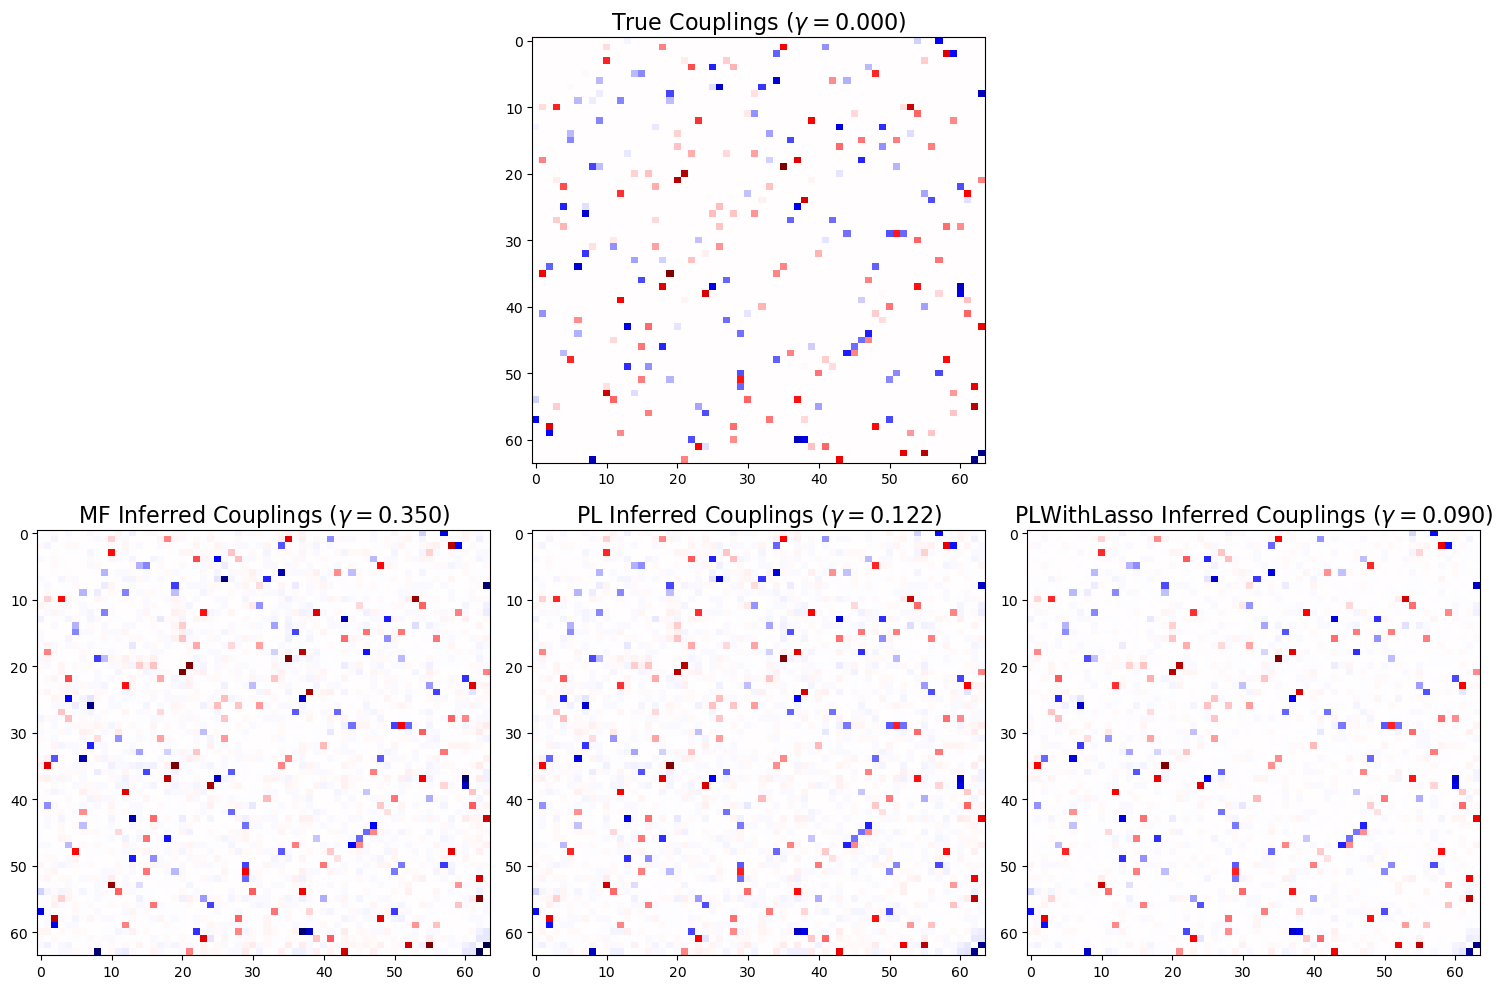

In [13]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=fig)

# Define vmin and vmax for consistent colormap scaling
x = max(abs(trueCouplings.min()), abs(trueCouplings.max()))
vmin = -x
vmax = x

# Plot trueCouplings in the first row (centered)
ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(trueCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax1.set_title(r'True Couplings ($\gamma = {:.3f}$)'.format(true_gamma), fontsize=16)
# ax1.set_xlabel('Index', fontsize=14)
# ax1.set_ylabel('Index', fontsize=14)

# Plot MF_inferredCouplings in the second row
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(MF_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax2.set_title(r'MF Inferred Couplings ($\gamma = {:.3f}$)'.format(MF_gamma), fontsize=16)
# ax2.set_xlabel('Index', fontsize=14)
# ax2.set_ylabel('Index', fontsize=14)

# Plot PL_inferredCouplings in the second row
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(PL_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax3.set_title(r'PL Inferred Couplings ($\gamma = {:.3f}$)'.format(PL_gamma), fontsize=16)
# ax3.set_xlabel('Index', fontsize=14)
# ax3.set_ylabel('Index', fontsize=14)

# Plot PLWithLasso_inferredCouplings in the second row
ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(PLWithLasso_inferredCouplings, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
ax4.set_title(r'PLWithLasso Inferred Couplings ($\gamma = {:.3f}$)'.format(PLWithLasso_gamma), fontsize=16)
# ax4.set_xlabel('Index', fontsize=14)
# ax4.set_ylabel('Index', fontsize=14)

plt.tight_layout()
plt.savefig('../imgs/couplingsInference_rrgDis_T{:.3f}.png'.format(1/beta))

--- 